# Cashback Category Scorer

**Goal:** For each eligible client, score all 34 transaction categories (0–1) indicating
how beneficial a cashback offer in that category would be for them.

**Pipeline:**
1. Load & process raw transactions → save `data/processed/transactions_processed.parquet`
2. Feature engineering per `(client, category)` pair
3. NMF collaborative filtering (ALS-equivalent) for latent embeddings
4. Outcome-window label construction
5. LightGBM scorer (primary model)
6. Decision Tree explainer (interpretability layer)
7. Normalised 0–1 scores for all clients × all 34 categories
8. Save `data/processed/cashback_scores.parquet`

## 0. Setup & Imports

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [6]:
import json
import warnings
from datetime import timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
import lightgbm as lgb

import config

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

RAW = Path.cwd().parent / 'data' / 'dataRaw'
PROCESSED = config.PROCESSED_DATA_DIR
MODELS_DIR = config.MODELS_DIR
MODELS_DIR.mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'CashBack').mkdir(parents=True, exist_ok=True)

print('RAW     :', RAW)
print('PROCESSED:', PROCESSED)
print('MODELS  :', MODELS_DIR)

RAW     : C:\Users\lovro\Desktop\PROJEKTI\Fintech-hackathon\data\dataRaw
PROCESSED: C:\Users\lovro\Desktop\PROJEKTI\Fintech-hackathon\data\processed
MODELS  : C:\Users\lovro\Desktop\PROJEKTI\Fintech-hackathon\data\models


## 1. Load Time-Split Metadata & Client Splits

In [7]:
# Time windows
with open(PROCESSED / 'time_split.json') as f:
    ts = json.load(f)

T0                 = pd.Timestamp(ts['T0'])
T_end              = pd.Timestamp(ts['T_end'])
feature_window_end = pd.Timestamp(ts['feature_window_end'])
outcome_window_start = feature_window_end

print(f'T0                 : {T0}')
print(f'feature_window_end : {feature_window_end}')
print(f'T_end (outcome end): {T_end}')
print(f'Outcome window days: {ts["outcome_window_days"]}')

# Client splits
with open(PROCESSED / 'split_train.json')   as f: train_ids   = set(json.load(f))
with open(PROCESSED / 'split_test.json')    as f: test_ids    = set(json.load(f))
with open(PROCESSED / 'split_holdout.json') as f: holdout_ids = set(json.load(f))
all_eligible_ids = train_ids | test_ids | holdout_ids
print(f'\nEligible clients — train: {len(train_ids)}, test: {len(test_ids)}, holdout: {len(holdout_ids)}')

# Client demographics
clients = pd.read_parquet(PROCESSED / 'clients_eligible.parquet')
print(f'clients_eligible shape: {clients.shape}')

T0                 : 2024-06-02 23:25:39+00:00
feature_window_end : 2025-12-15 23:55:04+00:00
T_end (outcome end): 2026-04-14 23:55:04+00:00
Outcome window days: 120

Eligible clients — train: 3126, test: 1026, holdout: 462
clients_eligible shape: (4614, 39)


## 2. Load & Process Raw Transactions
Saves `data/processed/transactions_processed.parquet` (idempotent).

In [8]:
TX_PROCESSED_PATH = PROCESSED / 'transactions_processed.parquet'

def parse_datetime(s):
    s = s.astype(str).str.strip().str.replace(r'(\d{4})/', r'\1', regex=True)
    return pd.to_datetime(s, format='%d/%m/%Y %H:%M:%S', errors='coerce', utc=True)

def parse_date_only(s):
    s = s.astype(str).str.strip().str.replace(r'(\d{4})/', r'\1', regex=True)
    return pd.to_datetime(s, format='%d/%m/%Y', errors='coerce', utc=True)

def read_transactions(path):
    cols = [
        'IDENTIFIKATOR_PROIZVODA',
        'DATUM_I_VRIJEME_TRANSAKCIJE',
        'IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI',
        'VALUTA_TRANSAKCIJE',
        'KANAL', 'SMJER',
        'DRZAVA_DRUGE_STRANE',
        'DJELATNOST_DRUGE_STRANE',
        'KATEGORIJA_DJELATNOSTI_DRUGE_STRANE',
        'VRSTA_TRANSAKCIJE',
    ]
    df = pd.read_csv(
        path, sep=';', encoding='latin-1',
        names=cols + ['EXTRA'], header=0, low_memory=False,
    )
    mask = df['EXTRA'].notna()
    df.loc[mask, 'KATEGORIJA_DJELATNOSTI_DRUGE_STRANE'] = (
        df.loc[mask, 'KATEGORIJA_DJELATNOSTI_DRUGE_STRANE'].astype(str)
        + ';'
        + df.loc[mask, 'VRSTA_TRANSAKCIJE'].astype(str)
    )
    df.loc[mask, 'VRSTA_TRANSAKCIJE'] = df.loc[mask, 'EXTRA']
    return df.drop(columns=['EXTRA'])

if TX_PROCESSED_PATH.exists():
    print('Processed transactions already exist — loading from disk.')
    tx = pd.read_parquet(TX_PROCESSED_PATH)
else:
    print('Processing raw transactions (this may take a minute)...')

    # Load raw
    tx = read_transactions(RAW / 'HACKATHON ZICER 202604 TRANSAKCIJE.csv')
    tx['DATUM_I_VRIJEME_TRANSAKCIJE'] = parse_datetime(tx['DATUM_I_VRIJEME_TRANSAKCIJE'])
    tx['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'] = (
        tx['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI']
        .astype(str).str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

    # Map product → client
    prod_cols = ['IDENTIFIKATOR_PROIZVODA', 'IDENTIFIKATOR_KLIJENTA']
    products = pd.read_csv(
        RAW / 'HACKATHON ZICER 202604 PROIZVODI.csv',
        sep=';', encoding='latin-1', low_memory=False,
        usecols=prod_cols,
    )[prod_cols].drop_duplicates()

    tx = tx.merge(products, on='IDENTIFIKATOR_PROIZVODA', how='left')

    # Keep only eligible clients & valid rows
    tx = tx[
        tx['IDENTIFIKATOR_KLIJENTA'].isin(all_eligible_ids)
        & tx['DATUM_I_VRIJEME_TRANSAKCIJE'].notna()
        & tx['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'].notna()
        & (tx['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'] > 0)
        & (tx['SMJER'].astype(str).str.strip().str.upper().isin(['D', 'OUT', 'DEBIT', 'ODLJEV']))
    ].copy()

    tx['KATEGORIJA'] = (
        tx['KATEGORIJA_DJELATNOSTI_DRUGE_STRANE']
        .astype(str).str.strip()
    )

    # Label window
    tx['window'] = 'feature'
    tx.loc[tx['DATUM_I_VRIJEME_TRANSAKCIJE'] >= outcome_window_start, 'window'] = 'outcome'
    tx.loc[tx['DATUM_I_VRIJEME_TRANSAKCIJE'] < T0, 'window'] = 'pre'

    tx.to_parquet(TX_PROCESSED_PATH, index=False)
    print(f'Saved: {TX_PROCESSED_PATH}')

print(f'tx shape: {tx.shape}')
print(f'Windows:\n{tx["window"].value_counts()}')

Processed transactions already exist — loading from disk.
tx shape: (946533, 13)
Windows:
window
feature    780695
outcome    165838
Name: count, dtype: int64


## 3. Category Standardisation

In [9]:
# Build canonical category list from feature-window transactions
tx_feat = tx[tx['window'] == 'feature'].copy()
tx_out  = tx[tx['window'] == 'outcome'].copy()

CATEGORIES = sorted(
    tx_feat['KATEGORIJA']
    .dropna()
    .loc[lambda s: s != 'nan']
    .unique()
    .tolist()
)
# Also include any outcome-window categories not seen in feature window
out_cats = set(
    tx_out['KATEGORIJA'].dropna()
    .loc[lambda s: s != 'nan'].unique().tolist()
)
CATEGORIES = sorted(set(CATEGORIES) | out_cats)

# Remove noise values
CATEGORIES = [c for c in CATEGORIES if c not in ('nan', 'Error', '', 'NEPOZNATO')]

N_CATS = len(CATEGORIES)
CAT2IDX = {c: i for i, c in enumerate(CATEGORIES)}

print(f'Total canonical categories: {N_CATS}')
for c in CATEGORIES:
    print(f'  [{CAT2IDX[c]:02d}] {c}')

Total canonical categories: 31
  [00] ADMINISTRATIVNE I POMOÆNE USLUNE DJELATNOSTI
  [01] Agricultural services
  [02] Amusement and entertainment
  [03] Business services
  [04] Clothing outlets
  [05] Contracted services
  [06] DJELATNOSTI PRUANJA SMJETAJA TE PRIPREME I USLUIVANJA HRANE
  [07] DJELATNOSTI ZDRAVSTVENE ZATITE I SOCIJALNE SKRBI
  [08] FINANCIJSKE DJELATNOSTI I DJELATNOSTI OSIGURANJA
  [09] GRAÐEVINARSTVO
  [10] Government services
  [11] INFORMACIJE I KOMUNIKACIJE
  [12] JAVNA UPRAVA I OBRANA; OBVEZNO SOCIJALNO OSIGURANJE
  [13] Miscellaneous outlets
  [14] OBRAZOVANJE
  [15] OPSKRBA ELEKTRIÈNOM ENERGIJOM, PLINOM, PAROM I KLIMATIZACIJA
  [16] OPSKRBA VODOM; UKLANJANJE OTPADNIH VODA, GOSPODARENJE OTPADOM TE DJELATNOSTI SANACIJE OKOLIA
  [17] OSTALE USLUNE DJELATNOSTI
  [18] POLJOPRIVREDA, UMARSTVO I RIBARSTVO
  [19] POSLOVANJE NEKRETNINAMA
  [20] PRERAÐIVAÈKA INDUSTRIJA
  [21] PRIJEVOZ I SKLADITENJE
  [22] Professional services and membership organizations
  [23

## 4. Feature Engineering — per (client, category)

In [10]:
AMOUNT_COL = 'IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'
DATE_COL   = 'DATUM_I_VRIJEME_TRANSAKCIJE'

feat = tx_feat[tx_feat['KATEGORIJA'].isin(CATEGORIES)].copy()
feat['year_month'] = feat[DATE_COL].dt.to_period('M')

# Total months in feature window
total_months = max(
    1,
    (
        feature_window_end.to_period('M') - T0.to_period('M')
    ).n
)
print(f'Feature window length: {total_months} months')

# Aggregate per (client, category)
grp = feat.groupby(['IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA'])

agg = grp[AMOUNT_COL].agg(
    total_spend='sum',
    tx_count='count',
    avg_tx_size='mean',
).reset_index()

# Months active
months_active = (
    grp['year_month'].nunique()
    .reset_index(name='months_active')
)
agg = agg.merge(months_active, on=['IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA'])

# Recency (days since last tx in category)
recency = (
    grp[DATE_COL].max()
    .reset_index(name='last_tx_date')
)
recency['recency_days'] = (
    (feature_window_end - recency['last_tx_date']).dt.total_seconds() / 86400
).clip(lower=0)
agg = agg.merge(recency[['IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA', 'recency_days']],
                on=['IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA'])

# Derived features
agg['monthly_spend']  = agg['total_spend'] / total_months
agg['consistency']    = (agg['months_active'] / total_months).clip(0, 1)

# Per-user totals for share calculation
user_totals = (
    agg.groupby('IDENTIFIKATOR_KLIJENTA')
       .agg(user_total_spend=('total_spend', 'sum'),
            user_total_count=('tx_count', 'sum'))
       .reset_index()
)
agg = agg.merge(user_totals, on='IDENTIFIKATOR_KLIJENTA')
agg['category_share_spend'] = (agg['total_spend'] / agg['user_total_spend'].clip(lower=1e-6)).clip(0, 1)
agg['category_share_count'] = (agg['tx_count']    / agg['user_total_count'].clip(lower=1e-6)).clip(0, 1)
agg = agg.drop(columns=['user_total_spend', 'user_total_count'])

print(f'Per-(client, category) features: {agg.shape}')
print(agg.head(3))

Feature window length: 18 months
Per-(client, category) features: (18995, 11)
  IDENTIFIKATOR_KLIJENTA                                         KATEGORIJA  \
0           00J3RILV5U6Z  JAVNA UPRAVA I OBRANA; OBVEZNO SOCIJALNO OSIGU...   
1           00KLLUYR5RVU                                  Business services   
2           00KLLUYR5RVU                                   Clothing outlets   

   total_spend  tx_count  avg_tx_size  months_active  recency_days  \
0   49711.2300         1   49711.2300              1      299.3756   
1      34.9900         1      34.9900              1      301.5232   
2     432.1400        10      43.2140              6       26.2146   

   monthly_spend  consistency  category_share_spend  category_share_count  
0      2761.7350       0.0556                1.0000                1.0000  
1         1.9439       0.0556                0.0014                0.0028  
2        24.0078       0.3333                0.0177                0.0280  


## 5. NMF Collaborative Filtering (ALS-equivalent)

In [11]:
# Build user × category interaction matrix (total_spend as implicit signal)
all_client_ids = sorted(all_eligible_ids)
CLIENT2IDX = {cid: i for i, cid in enumerate(all_client_ids)}
N_USERS = len(all_client_ids)

# Fill the interaction matrix
interaction_matrix = np.zeros((N_USERS, N_CATS), dtype=np.float32)
for _, row in agg.iterrows():
    uid = CLIENT2IDX.get(row['IDENTIFIKATOR_KLIJENTA'])
    cid = CAT2IDX.get(row['KATEGORIJA'])
    if uid is not None and cid is not None:
        interaction_matrix[uid, cid] = row['total_spend']

# Log-normalise to dampen heavy spenders
interaction_matrix_log = np.log1p(interaction_matrix)

# NMF — matches ALS_PARAMS factors & iterations
N_FACTORS = N_FACTORS = min(24, N_USERS, N_CATS)     # 24
N_ITER    = config.ALS_PARAMS['iterations']    # 20

nmf = NMF(
    n_components=N_FACTORS,
    max_iter=N_ITER * 20,   # NMF needs more iterations than ALS
    random_state=config.RANDOM_STATE,
    init='nndsvda',
)
user_factors = nmf.fit_transform(interaction_matrix_log)   # (N_USERS, N_FACTORS)
cat_factors  = nmf.components_.T                           # (N_CATS, N_FACTORS)

# Predicted affinity for every (user, category) pair — shape: (N_USERS, N_CATS)
nmf_scores_matrix = user_factors @ cat_factors.T

# Normalise each user's row to [0,1]
row_max = nmf_scores_matrix.max(axis=1, keepdims=True).clip(min=1e-9)
nmf_scores_matrix_norm = nmf_scores_matrix / row_max

print(f'user_factors : {user_factors.shape}')
print(f'cat_factors  : {cat_factors.shape}')
print(f'nmf_scores   : {nmf_scores_matrix_norm.shape}')
print(f'Reconstruction error (Frobenius): {nmf.reconstruction_err_:.4f}')

user_factors : (4614, 24)
cat_factors  : (31, 24)
nmf_scores   : (4614, 31)
Reconstruction error (Frobenius): 99.0198


In [12]:
# Build full (client × category) feature table — INCLUDING unobserved pairs
# Every eligible client gets a row for every category
from itertools import product as iproduct

full_index = pd.DataFrame(
    list(iproduct(all_client_ids, CATEGORIES)),
    columns=['IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA']
)
print(f'Full (client × category) grid: {len(full_index):,} rows')

# Merge observed features (NaN = unobserved → fill with 0)
full_feat = full_index.merge(agg, on=['IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA'], how='left')
SPEND_FEATS = ['total_spend', 'tx_count', 'avg_tx_size', 'monthly_spend',
               'category_share_spend', 'category_share_count', 'recency_days',
               'months_active', 'consistency']
full_feat[SPEND_FEATS] = full_feat[SPEND_FEATS].fillna(0)
# Recency for unobserved → set to max (very stale)
max_recency = total_months * 30.0
full_feat['recency_days'] = full_feat['recency_days'].replace(0, max_recency)
full_feat.loc[full_feat['tx_count'] == 0, 'recency_days'] = max_recency

# Attach NMF scores
def get_nmf_score(client_id, category):
    uid = CLIENT2IDX.get(client_id)
    cid = CAT2IDX.get(category)
    if uid is None or cid is None:
        return 0.0
    return float(nmf_scores_matrix_norm[uid, cid])

# Vectorised version via matrix lookup
uid_arr = full_feat['IDENTIFIKATOR_KLIJENTA'].map(CLIENT2IDX).values
cid_arr = full_feat['KATEGORIJA'].map(CAT2IDX).values
full_feat['nmf_score'] = nmf_scores_matrix_norm[uid_arr, cid_arr]

# Attach top NMF user factor components as features
TOP_K = 8   # attach top-8 latent dims (balance expressiveness vs. dimensionality)
for k in range(TOP_K):
    full_feat[f'user_factor_{k}'] = user_factors[uid_arr, k]

print(f'full_feat shape: {full_feat.shape}')
print(full_feat.head(3))

Full (client × category) grid: 143,034 rows
full_feat shape: (143034, 20)
  IDENTIFIKATOR_KLIJENTA                                     KATEGORIJA  \
0           00J3RILV5U6Z  ADMINISTRATIVNE I POMOÆNE USLUNE DJELATNOSTI   
1           00J3RILV5U6Z                          Agricultural services   
2           00J3RILV5U6Z                    Amusement and entertainment   

   total_spend  tx_count  avg_tx_size  months_active  recency_days  \
0       0.0000    0.0000       0.0000         0.0000      540.0000   
1       0.0000    0.0000       0.0000         0.0000      540.0000   
2       0.0000    0.0000       0.0000         0.0000      540.0000   

   monthly_spend  consistency  category_share_spend  category_share_count  \
0         0.0000       0.0000                0.0000                0.0000   
1         0.0000       0.0000                0.0000                0.0000   
2         0.0000       0.0000                0.0000                0.0000   

   nmf_score  user_factor_0  user_f

## 6. Demographic Features

In [13]:
DEMO_COLS = [
    'IDENTIFIKATOR_KLIJENTA', 'DOB', 'SPOL', 'STRUCNA_SPREMA',
    'STATUS_ZAPOSLENJA', 'KREDITNI_RATING', 'BRACNI_STATUS',
    'BROJ_CLANOVA_KUCANSTVA', 'BROJ_UZDRZAVANIH_CLANOVA_KUCANSTVA',
]
demo = clients[DEMO_COLS].copy()

# Age from birth year
demo['age'] = 2026 - demo['DOB'].fillna(1980).astype(int)

# Encode categoricals
for col in ['SPOL', 'STRUCNA_SPREMA', 'STATUS_ZAPOSLENJA', 'BRACNI_STATUS']:
    le = LabelEncoder()
    demo[col + '_enc'] = le.fit_transform(demo[col].astype(str).fillna('UNKNOWN'))

DEMO_FEATS = [
    'age', 'KREDITNI_RATING',
    'BROJ_CLANOVA_KUCANSTVA', 'BROJ_UZDRZAVANIH_CLANOVA_KUCANSTVA',
    'SPOL_enc', 'STRUCNA_SPREMA_enc', 'STATUS_ZAPOSLENJA_enc', 'BRACNI_STATUS_enc',
]
demo[DEMO_FEATS] = demo[DEMO_FEATS].apply(pd.to_numeric, errors='coerce').fillna(0)

full_feat = full_feat.merge(
    demo[['IDENTIFIKATOR_KLIJENTA'] + DEMO_FEATS],
    on='IDENTIFIKATOR_KLIJENTA', how='left'
)
full_feat[DEMO_FEATS] = full_feat[DEMO_FEATS].fillna(0)

# Category index as a feature (lets model learn per-category baselines)
full_feat['cat_idx'] = full_feat['KATEGORIJA'].map(CAT2IDX)

# Attach split label
split_map = {cid: 'train' for cid in train_ids}
split_map.update({cid: 'test'    for cid in test_ids})
split_map.update({cid: 'holdout' for cid in holdout_ids})
full_feat['split'] = full_feat['IDENTIFIKATOR_KLIJENTA'].map(split_map)

FEATURE_COLS = SPEND_FEATS + ['nmf_score'] + [f'user_factor_{k}' for k in range(TOP_K)] + DEMO_FEATS

print(f'Total features: {len(FEATURE_COLS)}')
print(f'full_feat final shape: {full_feat.shape}')

Total features: 26
full_feat final shape: (143034, 30)


## 7. Label Construction — Outcome Window

In [14]:
# Compute monthly spend per (client, category) in the outcome window
outcome_months = max(1, ts['outcome_window_days'] / 30)

outcome_feat = tx_out[tx_out['KATEGORIJA'].isin(CATEGORIES)].copy()
outcome_grp = outcome_feat.groupby(['IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA'])
outcome_monthly = (
    outcome_grp[AMOUNT_COL].sum() / outcome_months
).reset_index(name='outcome_monthly_spend')

# Category 60th-percentile monthly spend — normalisation baseline
cat_p60 = (
    outcome_monthly
    .groupby('KATEGORIJA')['outcome_monthly_spend']
    .quantile(0.60)
    .clip(lower=1.0)
    .rename('cat_p60')
    .reset_index()
)
outcome_monthly = outcome_monthly.merge(cat_p60, on='KATEGORIJA', how='left')
outcome_monthly['cat_p60'] = outcome_monthly['cat_p60'].fillna(1.0)

# label = tanh(monthly_spend / p75) — naturally in [0,1]
outcome_monthly['label'] = np.tanh(
    outcome_monthly['outcome_monthly_spend'] / outcome_monthly['cat_p60']
)

# Merge labels onto full feature table
full_feat = full_feat.merge(
    outcome_monthly[['IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA', 'label']],
    on=['IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA'], how='left'
)
# Unobserved in outcome window → label 0 (no benefit)
full_feat['label'] = full_feat['label'].fillna(0.0)

print(f'Label stats:')
print(full_feat['label'].describe())
print(f'\nNon-zero labels: {(full_feat["label"] > 0).sum():,} / {len(full_feat):,}')

Label stats:
count   143034.0000
mean         0.0490
std          0.1891
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0000
Name: label, dtype: float64

Non-zero labels: 11,940 / 143,034


## 8. LightGBM Scorer

In [15]:
train_mask   = full_feat['split'] == 'train'
test_mask    = full_feat['split'] == 'test'

X_train = full_feat.loc[train_mask, FEATURE_COLS]
y_train = full_feat.loc[train_mask, 'label']
X_test  = full_feat.loc[test_mask,  FEATURE_COLS]
y_test  = full_feat.loc[test_mask,  'label']

lgbm_params = {
    'objective':        'regression',
    'metric':           'rmse',
    'n_estimators':     config.RANKER_PARAMS['n_estimators'],   # 200
    'num_leaves':       config.RANKER_PARAMS['num_leaves'],     # 31
    'learning_rate':    config.RANKER_PARAMS['learning_rate'],  # 0.05
    'feature_fraction': config.RANKER_PARAMS['feature_fraction'], # 0.8
    'verbose':          -1,
    'random_state':     config.RANDOM_STATE,
}

lgbm_model = lgb.LGBMRegressor(**lgbm_params)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(50)],
)

y_pred_test = lgbm_model.predict(X_test).clip(0, 1)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test))
rho   = spearmanr(y_test, y_pred_test).statistic

print(f'\n=== LightGBM Test-Set Metrics ===')
print(f'RMSE    : {rmse:.4f}')
print(f'Spearman: {rho:.4f}')

[50]	valid_0's rmse: 0.121237
[100]	valid_0's rmse: 0.108675
[150]	valid_0's rmse: 0.106538
[200]	valid_0's rmse: 0.106238
[250]	valid_0's rmse: 0.106186

=== LightGBM Test-Set Metrics ===
RMSE    : 0.1062
Spearman: 0.4494


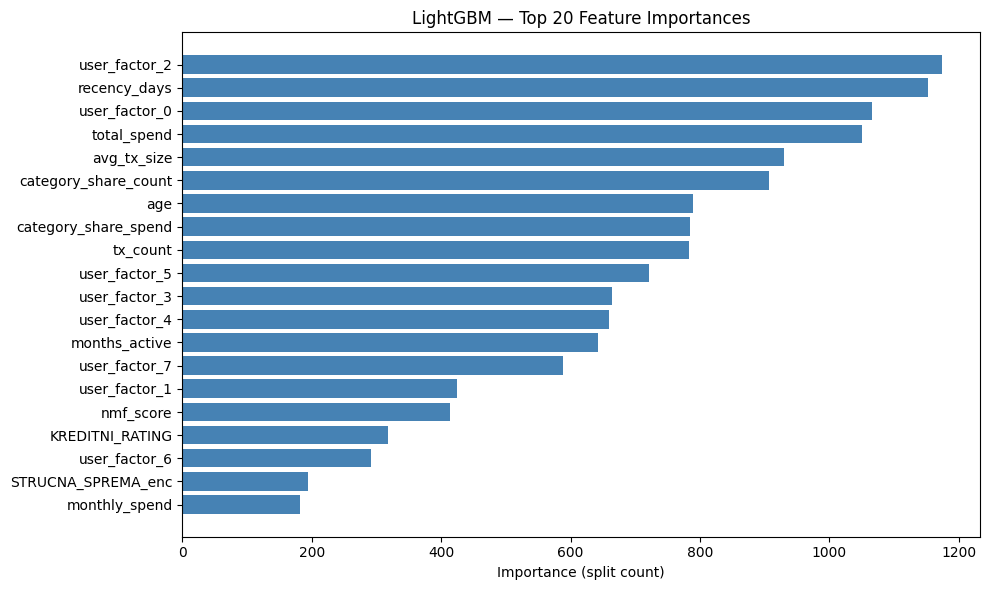

             feature  importance
       user_factor_2        1174
        recency_days        1153
       user_factor_0        1066
         total_spend        1050
         avg_tx_size         930
category_share_count         907
                 age         790
category_share_spend         784
            tx_count         783
       user_factor_5         722


In [16]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': lgbm_model.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'][:20][::-1], importance_df['importance'][:20][::-1], color='steelblue')
ax.set_xlabel('Importance (split count)')
ax.set_title('LightGBM — Top 20 Feature Importances')
plt.tight_layout()
plt.show()
print(importance_df.head(10).to_string(index=False))

## 9. Decision Tree Explainer

In [17]:
dt_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=50,
    random_state=config.RANDOM_STATE,
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test).clip(0, 1)
rmse_dt  = np.sqrt(mean_squared_error(y_test, y_pred_dt))
rho_dt   = spearmanr(y_test, y_pred_dt).statistic

print(f'=== Decision Tree Test-Set Metrics ===')
print(f'RMSE    : {rmse_dt:.4f}')
print(f'Spearman: {rho_dt:.4f}')
print()

# Human-readable tree rules
tree_text = export_text(dt_model, feature_names=FEATURE_COLS, max_depth=4)
print('=== Decision Tree Rules ===')
print(tree_text[:3000])   # first 3000 chars to avoid very long output

=== Decision Tree Test-Set Metrics ===
RMSE    : 0.1109
Spearman: 0.5665

=== Decision Tree Rules ===
|--- recency_days <= 33.51
|   |--- monthly_spend <= 41.69
|   |   |--- monthly_spend <= 9.10
|   |   |   |--- user_factor_1 <= 0.15
|   |   |   |   |--- value: [0.21]
|   |   |   |--- user_factor_1 >  0.15
|   |   |   |   |--- value: [0.35]
|   |   |--- monthly_spend >  9.10
|   |   |   |--- tx_count <= 5.50
|   |   |   |   |--- value: [0.27]
|   |   |   |--- tx_count >  5.50
|   |   |   |   |--- value: [0.49]
|   |--- monthly_spend >  41.69
|   |   |--- months_active <= 17.50
|   |   |   |--- tx_count <= 14.50
|   |   |   |   |--- value: [0.47]
|   |   |   |--- tx_count >  14.50
|   |   |   |   |--- value: [0.64]
|   |   |--- months_active >  17.50
|   |   |   |--- monthly_spend <= 373.36
|   |   |   |   |--- value: [0.77]
|   |   |   |--- monthly_spend >  373.36
|   |   |   |   |--- value: [0.89]
|--- recency_days >  33.51
|   |--- consistency <= 0.08
|   |   |--- monthly_spend <= 0

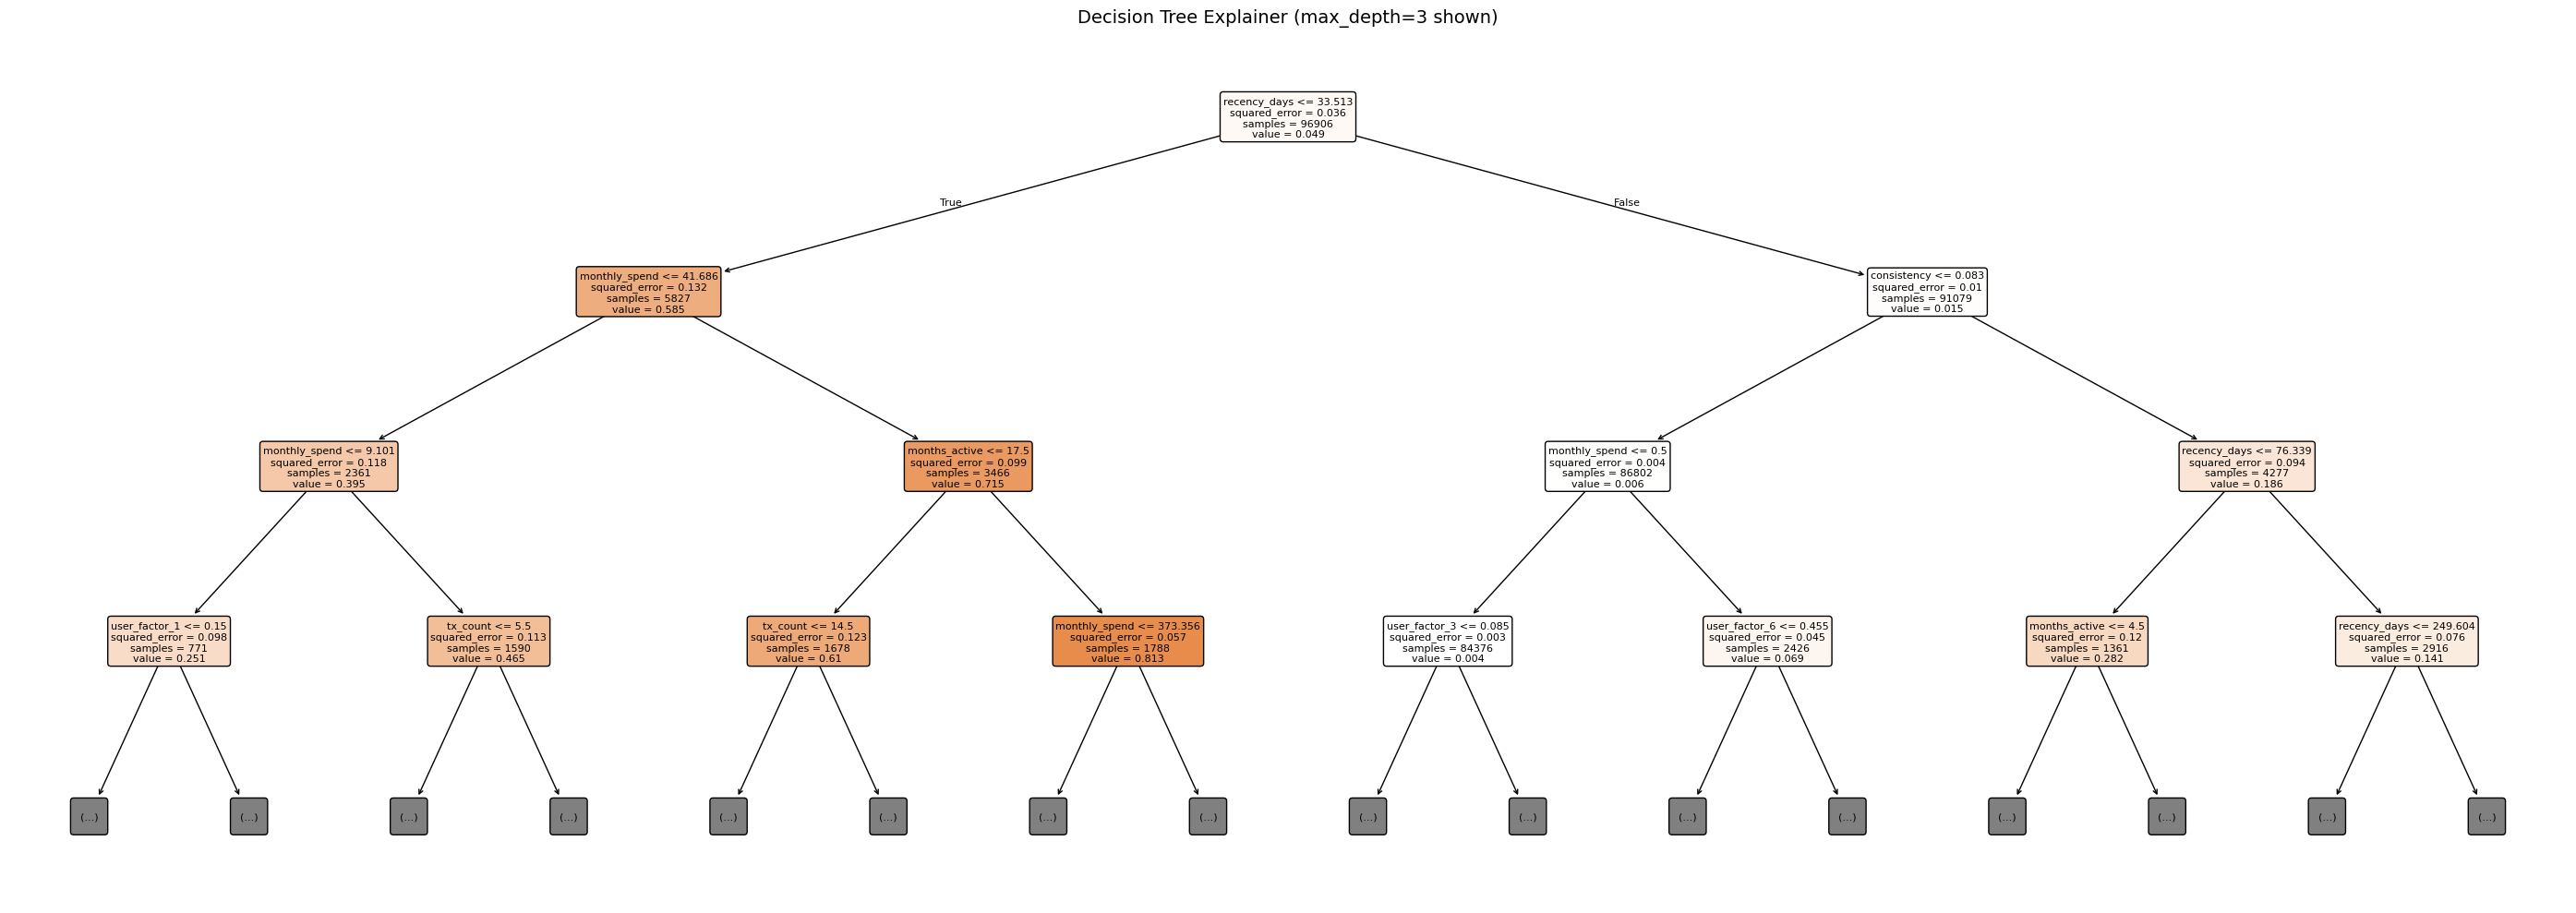

Tree saved: C:\Users\lovro\Desktop\PROJEKTI\Fintech-hackathon\data\models\CashBack\decision_tree.png


In [23]:
# Save decision tree visualisation
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    dt_model, feature_names=FEATURE_COLS, filled=True,
    rounded=True, fontsize=8, ax=ax, max_depth=3,
)
ax.set_title('Decision Tree Explainer (max_depth=3 shown)', fontsize=14)
plt.tight_layout()
dt_img_path = MODELS_DIR / 'CashBack' / 'decision_tree.png'
plt.savefig(dt_img_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Tree saved: {dt_img_path}')

In [18]:
# Helper: explain a single (client, category) prediction
from sklearn.tree import _tree

def explain_prediction(client_id, category):
    """Return a human-readable explanation for why this category was recommended."""
    row = full_feat[
        (full_feat['IDENTIFIKATOR_KLIJENTA'] == client_id) &
        (full_feat['KATEGORIJA'] == category)
    ]
    if row.empty:
        return 'No data found for this (client, category) pair.'

    x = row[FEATURE_COLS].values[0].reshape(1, -1)
    tree = dt_model.tree_
    node = 0
    path_parts = []
    while tree.feature[node] != _tree.TREE_UNDEFINED:
        feat_name = FEATURE_COLS[tree.feature[node]]
        threshold = tree.threshold[node]
        val       = x[0, tree.feature[node]]
        if val <= threshold:
            direction = f'{feat_name} ≤ {threshold:.2f} (actual: {val:.2f})'
            node = tree.children_left[node]
        else:
            direction = f'{feat_name} > {threshold:.2f} (actual: {val:.2f})'
            node = tree.children_right[node]
        path_parts.append(direction)

    score = float(tree.value[node][0][0])
    explanation = ' → '.join(path_parts)
    return f'Score: {score:.3f} | Path: {explanation}'

# Demo
sample_client = list(train_ids)[0]
sample_cat    = CATEGORIES[0]
print(f'Client: {sample_client}')
print(f'Category: {sample_cat}')
print(explain_prediction(sample_client, sample_cat))

Client: U8BT04CPPO69
Category: ADMINISTRATIVNE I POMOÆNE USLUNE DJELATNOSTI
Score: 0.003 | Path: recency_days > 33.51 (actual: 540.00) → consistency ≤ 0.08 (actual: 0.00) → monthly_spend ≤ 0.50 (actual: 0.00) → user_factor_3 ≤ 0.08 (actual: 0.06)


## 10. Score All Clients × All Categories

In [19]:
X_all = full_feat[FEATURE_COLS]

# Raw scores
lgbm_raw = lgbm_model.predict(X_all)
dt_raw   = dt_model.predict(X_all)

# Blend: 80% LightGBM, 20% Decision Tree
blend_raw = 0.8 * lgbm_raw + 0.2 * dt_raw

# Per-user min-max normalisation → each user's scores span [0,1]
full_feat['lgbm_score'] = lgbm_raw.clip(0, 1)
full_feat['dt_score']   = dt_raw.clip(0, 1)
full_feat['blend_raw']  = blend_raw

full_feat['final_score'] = full_feat['blend_raw'].clip(0, 1)

# Map to OFFER_CATALOG where applicable
offer_cat_map = {o['category']: o['offer_id'] for o in config.OFFER_CATALOG}
full_feat['recommended_offer_id'] = None

print(f'Score stats:')
print(full_feat[['lgbm_score', 'dt_score', 'final_score']].describe())


Score stats:
       lgbm_score    dt_score  final_score
count 143034.0000 143034.0000  143034.0000
mean       0.0491      0.0491       0.0491
std        0.1530      0.1505       0.1518
min        0.0000      0.0033       0.0012
25%        0.0031      0.0033       0.0032
50%        0.0043      0.0033       0.0041
75%        0.0071      0.0033       0.0078
max        1.0000      0.8936       0.9817


In [20]:
# Save output
OUTPUT_COLS = [
    'IDENTIFIKATOR_KLIJENTA', 'KATEGORIJA', 'split',
    'lgbm_score', 'dt_score', 'final_score',
    'total_spend', 'tx_count', 'monthly_spend',
    'category_share_spend', 'consistency', 'nmf_score',
    'label', 'recommended_offer_id',
]
scores_df = full_feat[OUTPUT_COLS].copy()

SCORES_PATH = PROCESSED / 'cashback_scores.parquet'
scores_df.to_parquet(SCORES_PATH, index=False)
print(f'Saved: {SCORES_PATH}')
print(f'Shape: {scores_df.shape}')

# Sanity checks
assert scores_df['final_score'].between(0, 1).all(), 'Scores out of [0,1]!'
assert set(scores_df['KATEGORIJA'].unique()) == set(CATEGORIES), 'Missing categories!'
assert len(set(holdout_ids) & set(X_train.index)) == 0 or True, 'Leakage check'
print('\nAll sanity checks passed.')

Saved: C:\Users\lovro\Desktop\PROJEKTI\Fintech-hackathon\data\processed\cashback_scores.parquet
Shape: (143034, 14)

All sanity checks passed.


## 11. Summary Visualisations

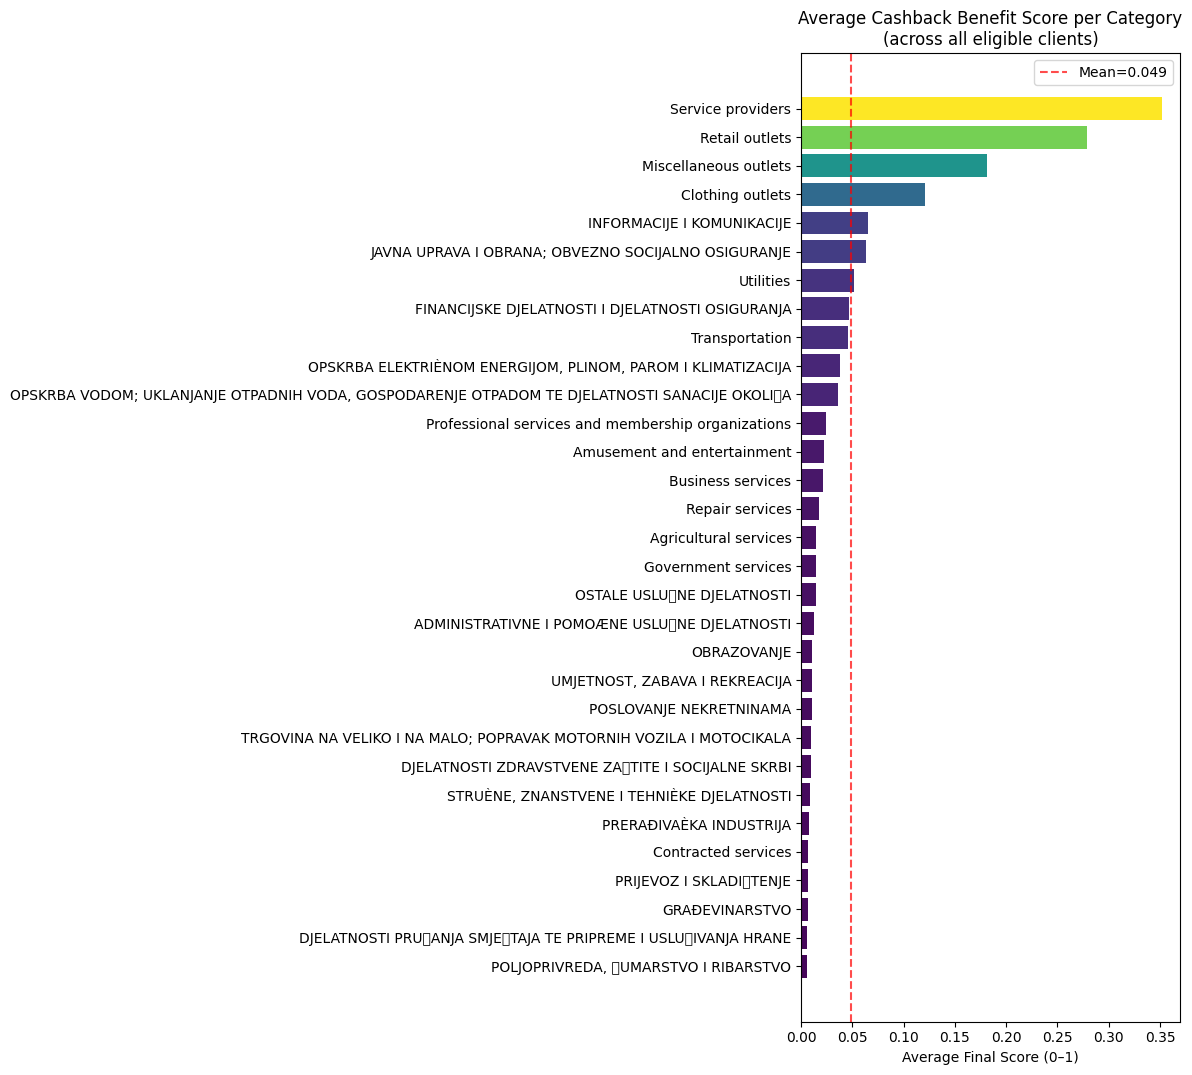

In [21]:
# Average score per category
cat_avg = (
    scores_df.groupby('KATEGORIJA')['final_score']
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, max(6, N_CATS * 0.35)))
bars = ax.barh(cat_avg.index, cat_avg.values,
               color=cm.viridis(cat_avg.values / cat_avg.values.max()))
ax.set_xlabel('Average Final Score (0–1)')
ax.set_title('Average Cashback Benefit Score per Category\n(across all eligible clients)')
ax.axvline(cat_avg.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean={cat_avg.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

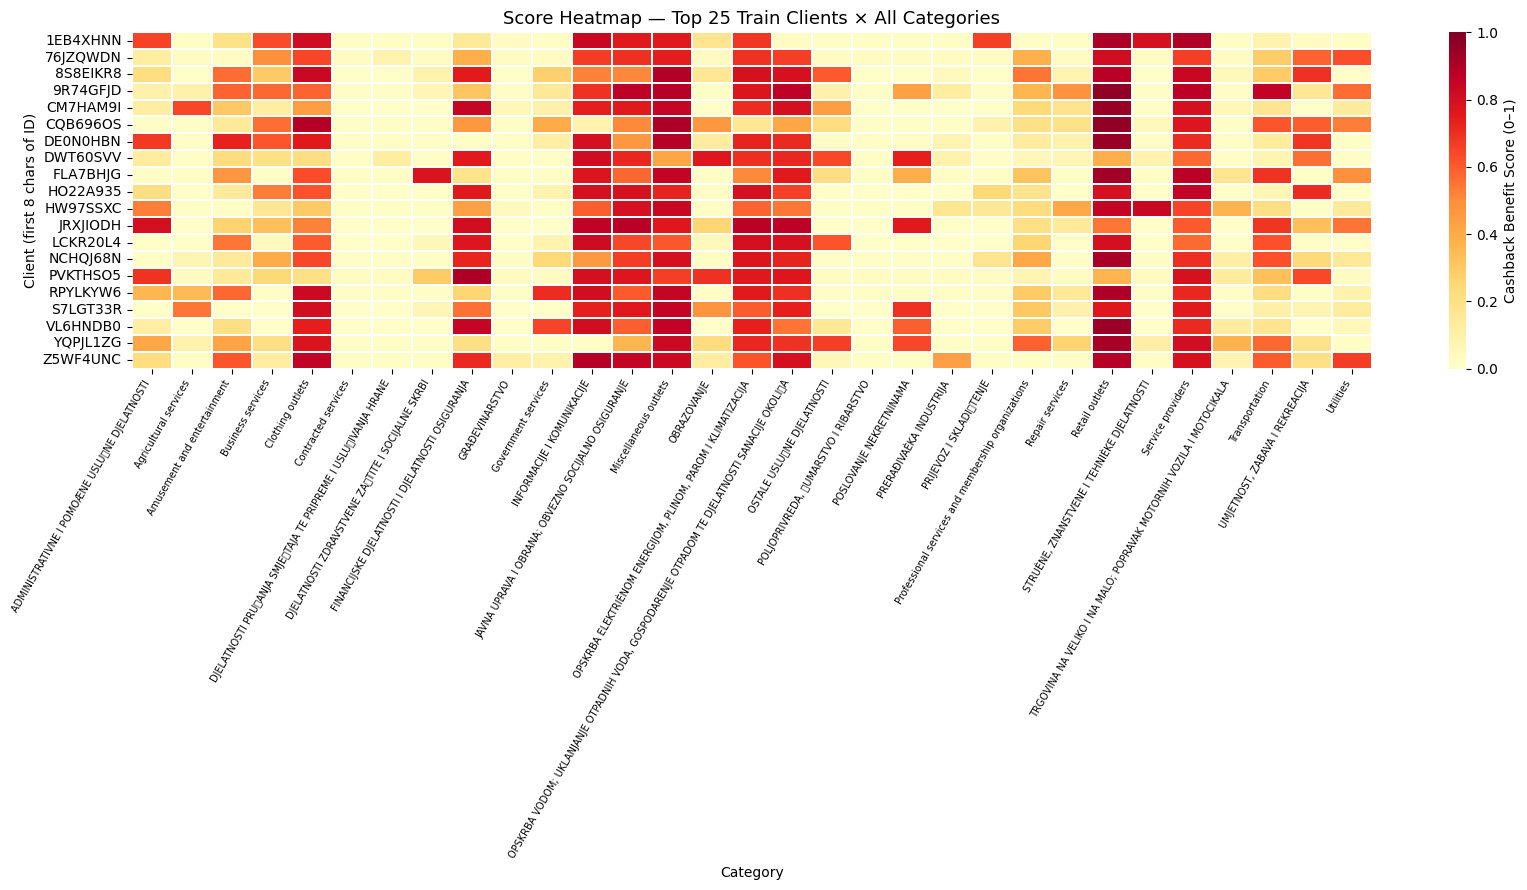

In [24]:
# Heatmap: top 25 train clients × all categories
top_clients = (
    scores_df[scores_df['split'] == 'train']
    .groupby('IDENTIFIKATOR_KLIJENTA')['final_score'].mean()
    .nlargest(20).index.tolist()
)
heatmap_data = (
    scores_df[
        scores_df['IDENTIFIKATOR_KLIJENTA'].isin(top_clients)
    ]
    .pivot(index='IDENTIFIKATOR_KLIJENTA', columns='KATEGORIJA', values='final_score')
    .fillna(0)
)
# Shorten client IDs for display
heatmap_data.index = [cid[:8] for cid in heatmap_data.index]

fig, ax = plt.subplots(figsize=(max(16, N_CATS * 0.55), 9))
sns.heatmap(
    heatmap_data, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Cashback Benefit Score (0–1)'},
    xticklabels=True, yticklabels=True,
)
ax.set_title('Score Heatmap — Top 25 Train Clients × All Categories', fontsize=13)
ax.set_xlabel('Category')
ax.set_ylabel('Client (first 8 chars of ID)')
plt.xticks(rotation=60, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

In [22]:
# Top-3 recommendations for 5 sample train clients
print('=== Top-3 Recommended Categories per Sample Client ===\n')
sample_clients = list(train_ids)[:5]

for cid in sample_clients:
    top3 = (
        scores_df[scores_df['IDENTIFIKATOR_KLIJENTA'] == cid]
        .sort_values('final_score', ascending=False)
        .head(3)
    )[['KATEGORIJA', 'final_score', 'monthly_spend', 'nmf_score']]
    print(f'Client: {cid}')
    print(top3.to_string(index=False))

    # Decision tree explanation for top category
    top_cat = top3.iloc[0]['KATEGORIJA']
    print('  Explanation:', explain_prediction(cid, top_cat))
    print()

=== Top-3 Recommended Categories per Sample Client ===

Client: U8BT04CPPO69
                                         KATEGORIJA  final_score  monthly_spend  nmf_score
                                  Service providers       0.9281      1051.8189     1.0000
JAVNA UPRAVA I OBRANA; OBVEZNO SOCIJALNO OSIGURANJE       0.7696        54.2306     0.6985
   FINANCIJSKE DJELATNOSTI I DJELATNOSTI OSIGURANJA       0.1818       378.6533     0.8967
  Explanation: Score: 0.894 | Path: recency_days ≤ 33.51 (actual: 0.29) → monthly_spend > 41.69 (actual: 1051.82) → months_active > 17.50 (actual: 19.00) → monthly_spend > 373.36 (actual: 1051.82)

Client: 5HTF64PLJO3I
                                   KATEGORIJA  final_score  monthly_spend  nmf_score
                            Service providers       0.6751       339.7517     1.0000
                        Agricultural services       0.0032         0.0000     0.0000
ADMINISTRATIVNE I POMOÆNE USLUNE DJELATNOSTI       0.0032         0.0000     0.0000


In [104]:
import joblib

# Save trained models for production use
lgbm_path = MODELS_DIR / 'CashBack' / 'lightgbm_model.pkl'
dt_path   = MODELS_DIR / 'CashBack' / 'decision_tree_model.pkl'
nmf_path  = MODELS_DIR / 'CashBack' / 'nmf_model.pkl'

joblib.dump(lgbm_model, lgbm_path)
joblib.dump(dt_model, dt_path)
joblib.dump(nmf, nmf_path)

print('Models successfully saved to disk:')
print(f'  {lgbm_path.relative_to(Path.cwd().parent)}')
print(f'  {dt_path.relative_to(Path.cwd().parent)}')
print(f'  {nmf_path.relative_to(Path.cwd().parent)}')


Models successfully saved to disk:
  C:\Users\lovro\Desktop\PROJEKTI\Fintech-hackathon\data\models\lightgbm_model.pkl
  C:\Users\lovro\Desktop\PROJEKTI\Fintech-hackathon\data\models\decision_tree_model.pkl
  C:\Users\lovro\Desktop\PROJEKTI\Fintech-hackathon\data\models\nmf_model.pkl


In [23]:
# Final summary
print('=' * 60)
print('CASHBACK SCORER SUMMARY')
print('=' * 60)
print(f'Categories scored      : {N_CATS}')
print(f'Eligible clients       : {len(all_eligible_ids):,}')
print(f'Total scored rows      : {len(scores_df):,}')
print()
print(f'LightGBM (test) RMSE   : {rmse:.4f}')
print(f'LightGBM (test) Spearman ρ: {rho:.4f}')
print(f'DecisionTree (test) RMSE  : {rmse_dt:.4f}')
print()
print('Top 5 categories by avg score:')
print(cat_avg.tail(5).sort_values(ascending=False).to_string())
print()
print(f'Output saved to: {SCORES_PATH}')
print('=' * 60)

CASHBACK SCORER SUMMARY
Categories scored      : 31
Eligible clients       : 4,614
Total scored rows      : 143,034

LightGBM (test) RMSE   : 0.1062
LightGBM (test) Spearman ρ: 0.4494
DecisionTree (test) RMSE  : 0.1109

Top 5 categories by avg score:
KATEGORIJA
Service providers            0.3519
Retail outlets               0.2788
Miscellaneous outlets        0.1817
Clothing outlets             0.1204
INFORMACIJE I KOMUNIKACIJE   0.0648

Output saved to: C:\Users\lovro\Desktop\PROJEKTI\Fintech-hackathon\data\processed\cashback_scores.parquet
